## Part 3: Advanced Text Processing - LDA and BERTopic Topic Modeling (20 pts)

**Resources:**
- LDA:
    - https://medium.com/sayahfares19/text-analysis-topic-modelling-with-spacy-gensim-4cd92ef06e06 
    - https://www.kaggle.com/code/faressayah/text-analysis-topic-modeling-with-spacy-gensim#%F0%9F%93%9A-Topic-Modeling (code for previous post)
    - https://towardsdatascience.com/topic-modelling-in-python-with-spacy-and-gensim-dc8f7748bdbf/ 
- BERTopic:
    - https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_documents.html#visualize-documents-with-plotly 
    - https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_topics.html 


In [13]:
from spacy import displacy
from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.feature_extraction.text import CountVectorizer
import pyLDAvis
import pyLDAvis.gensim_models
import spacy
nlp = spacy.load("en_core_web_sm")



import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


plt.style.use('seaborn-v0_8-dark')

# read in SOTU.csv
sou = pd.read_csv('data/SOTU.csv')


### LDA

- Train an LDA model with 18 topics
- Output the top 10 words for each topic. 
- Output the topic distribution for the first speech
- Make a visualization

You may use the next two cells to process the data.

In [14]:
def preprocess_text(text): 
    doc = nlp(text) 
    return [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 3]

In [15]:
# Process all texts - note this takes ~ 5 minutes to run
processed_docs = sou['Text'].apply(preprocess_text)

To train an LDA model, use the LdaModel function that we imported a couple of cells back. The last resource linked under the LDA section is especially useful for walking through the steps we have below. *Note: one of the arguments to the LdaModel function is `random_state` which specifies the random seed for reproducibility. Please set yours to 42. Further, the last resource provided uses `LdaMulticore` which is essentially a parallelizable version of our function `LdaModel`. Use `LdaModel` instead, but the usage will be similar, except you can ignore the `iterations` and `workers` arguments..*.

In [19]:
# Build dictionary from processed_docs, which is a list of tokens extracted from our speeches
dictionary = Dictionary(processed_docs)
# Here I convert to the bag of words corpus
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]


In [20]:
# train LDA model with 18 topics
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=18, random_state=42, passes=10)


In [37]:
# print the top 10 words for each topic
print("--- LDA Topics ---")

for topic_id, topic_words_with_weights in lda_model.show_topics(num_topics=-1, num_words=10, formatted=False):
    top_words = [word for word, weight in topic_words_with_weights]
    print(f"Topic {topic_id}: nWords: {topic}\n")


--- LDA Topics ---
Topic 0: nWords: 0.012*"government" + 0.011*"year" + 0.009*"states" + 0.007*"united" + 0.006*"congress" + 0.006*"country" + 0.005*"people" + 0.005*"increase" + 0.005*"great" + 0.004*"time"

Topic 1: nWords: 0.012*"government" + 0.011*"year" + 0.009*"states" + 0.007*"united" + 0.006*"congress" + 0.006*"country" + 0.005*"people" + 0.005*"increase" + 0.005*"great" + 0.004*"time"

Topic 2: nWords: 0.012*"government" + 0.011*"year" + 0.009*"states" + 0.007*"united" + 0.006*"congress" + 0.006*"country" + 0.005*"people" + 0.005*"increase" + 0.005*"great" + 0.004*"time"

Topic 3: nWords: 0.012*"government" + 0.011*"year" + 0.009*"states" + 0.007*"united" + 0.006*"congress" + 0.006*"country" + 0.005*"people" + 0.005*"increase" + 0.005*"great" + 0.004*"time"

Topic 4: nWords: 0.012*"government" + 0.011*"year" + 0.009*"states" + 0.007*"united" + 0.006*"congress" + 0.006*"country" + 0.005*"people" + 0.005*"increase" + 0.005*"great" + 0.004*"time"

Topic 5: nWords: 0.012*"governm

In [32]:
# print the topic distribution for the first speech
from numpy import float32

dominant_topic = max(lda_model.get_document_topics(corpus[0]), key=lambda x: x[1])

# Format as expected
formatted_output = [(dominant_topic[0], float32(dominant_topic[1]))]
print(formatted_output)



[(2, 0.9997302)]


In [34]:
# make a visualization using pyLDAvis
pyLDAvis.enable_notebook()

lda_vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)

lda_vis


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
10     0.126916  0.092949       1        1  26.283599
2      0.089284 -0.174943       2        1  15.504990
17     0.117006  0.053179       3        1  13.995266
7      0.112201 -0.004404       4        1  10.728196
8      0.116539 -0.046411       5        1   9.642928
14     0.125870 -0.144552       6        1   9.183211
6      0.133126  0.093991       7        1   8.601981
12     0.114190  0.118905       8        1   3.414113
0      0.075747 -0.015423       9        1   1.538420
3     -0.018253  0.093662      10        1   0.446517
11    -0.055536 -0.099118      11        1   0.440100
5     -0.090343 -0.028187      12        1   0.148217
1     -0.094623 -0.005792      13        1   0.063958
4     -0.146574  0.002310      14        1   0.001701
9     -0.166819  0.012717      15        1   0.001701
13    -0.121189  0.005410      16        1   0.001701
15    -0.145815  0.032866      17        1   0.001701
16    -0.171728  0.012842      18        1   0.001701, topic_info=            Term         Freq        Total Category  logprob  loglift
1524  government  8254.000000  8254.000000  Default  30.0000  30.0000
1249        year  7022.000000  7022.000000  Default  29.0000  29.0000
1065      states  6505.000000  6505.000000  Default  28.0000  28.0000
223     congress  5368.000000  5368.000000  Default  27.0000  27.0000
1184      united  5042.000000  5042.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
737     national     0.008145  2281.376237  Topic18  -7.4346  -1.5609
957        right     0.008154  2344.390268  Topic18  -7.4335  -1.5871
560     increase     0.007969  2777.310517  Topic18  -7.4566  -1.7796
1579    interest     0.007883  2693.553407  Topic18  -7.4673  -1.7597
50       america     0.007565  2101.956315  Topic18  -7.5086  -1.5530

[1496 rows x 6 columns], token_table=       Topic      Freq        Term
term                              
9251       2  0.036331       --the
9251       4  0.072663       --the
9251       5  0.036331       --the
9251       6  0.835621       --the
22222     10  0.827316   1,473,551
...      ...       ...         ...
11177      1  0.464543    yokohama
11177     11  0.464543    yokohama
22265     10  0.544885  zanesville
13334      1  0.971593      zelaya
20680      7  0.875049     zuloaga

[4082 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[11, 3, 18, 8, 9, 15, 7, 13, 1, 4, 12, 6, 2, 5, 10, 14, 16, 17])

### BERTopic

- Train a BERTopic model with a `min_topic_size` of 3 *Hint: use `BERTopic` to instantiate the model and specify `min_topic_size` in here. Actually fit the model using `fit_transform`, which `docs` passed into this.*
- Output the top 10 words for each topic. 
- Output the topic distribution for the first speech
- Make a visualization of the topics (see topic_model.visualize_topics())

In [85]:
docs = sou['Text'].to_list()

In [86]:
# train the model - this takes about 30 seconds

# remove stop words from the topics (Hint: use CountVectorizer and then .update_topics on topic_model)

2025-11-08 22:50:56,658 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 8/8 [00:08<00:00,  1.03s/it]
2025-11-08 22:51:09,053 - BERTopic - Embedding - Completed ✓
2025-11-08 22:51:09,054 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-08 22:51:19,326 - BERTopic - Dimensionality - Completed ✓
2025-11-08 22:51:19,327 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-08 22:51:19,342 - BERTopic - Cluster - Completed ✓
2025-11-08 22:51:19,346 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-08 22:51:20,853 - BERTopic - Representation - Completed ✓


In [87]:
# output the top 10 words for each topic - hint see get_topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,56,-1_states_government_united_congress,"[states, government, united, congress, country...",[\nTo the Congress of the United States:\nYour...
1,0,29,0_world_people_new_years,"[world, people, new, years, america, american,...","[\nMr. Speaker, Mr. President, my colleagues i..."
2,1,18,1_america_americans_american_people,"[america, americans, american, people, tonight...","[\nMr. Speaker, Vice President Cheney, Members..."
3,2,17,2_states_government_united_congress,"[states, government, united, congress, public,...",[\nTo the Senate and House of Representatives ...
4,3,15,3_states_government_united_law,"[states, government, united, law, congress, ye...",[\nTo the Senate and House of Representatives:...
5,4,12,4_government_work_public_congress,"[government, work, public, congress, great, la...",[\nTo the Senate and House of Representatives:...
6,5,11,5_world_peace_nations_soviet,"[world, peace, nations, soviet, nation, econom...","[\nMr. President, Mr. Speaker, Members of the ..."
7,6,9,6_british_states_united_war,"[british, states, united, war, enemy, great, f...",[\nFellow-Citizens of the Senate and House of ...
8,7,8,7_states_government_congress_united,"[states, government, congress, united, year, c...",[\nFellow-Citizens of the Senate and House of ...
9,8,8,8_america_americans_jobs_new,"[america, americans, jobs, new, american, that...","[\nMadam Speaker, Mr. Vice President, Members ..."


100%|██████████| 1/1 [00:14<00:00, 14.91s/it]


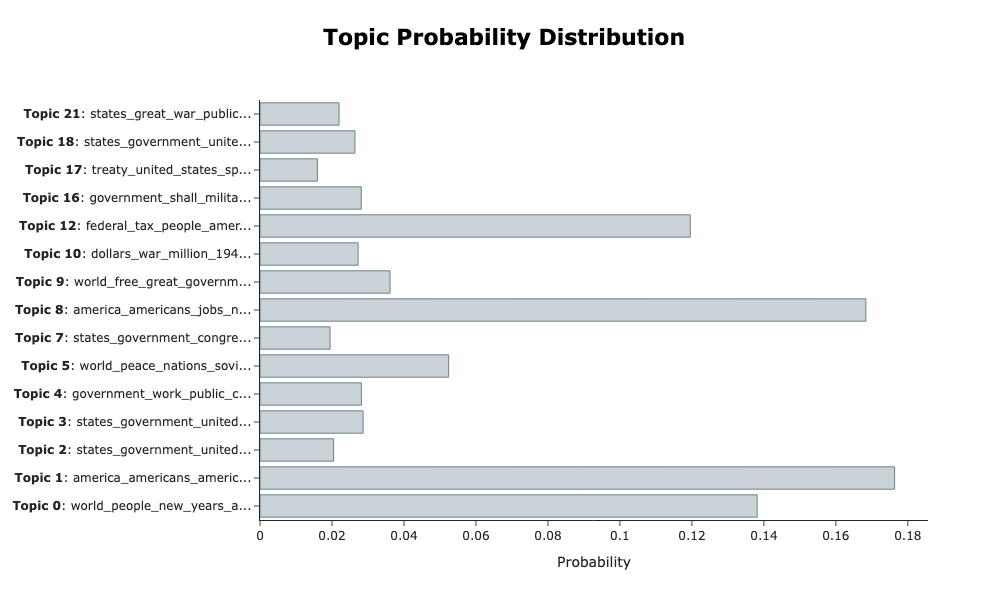

In [88]:
# output the topic distribution for the first speech
# hint: check out approximate_distribution() and visualize_distribution()

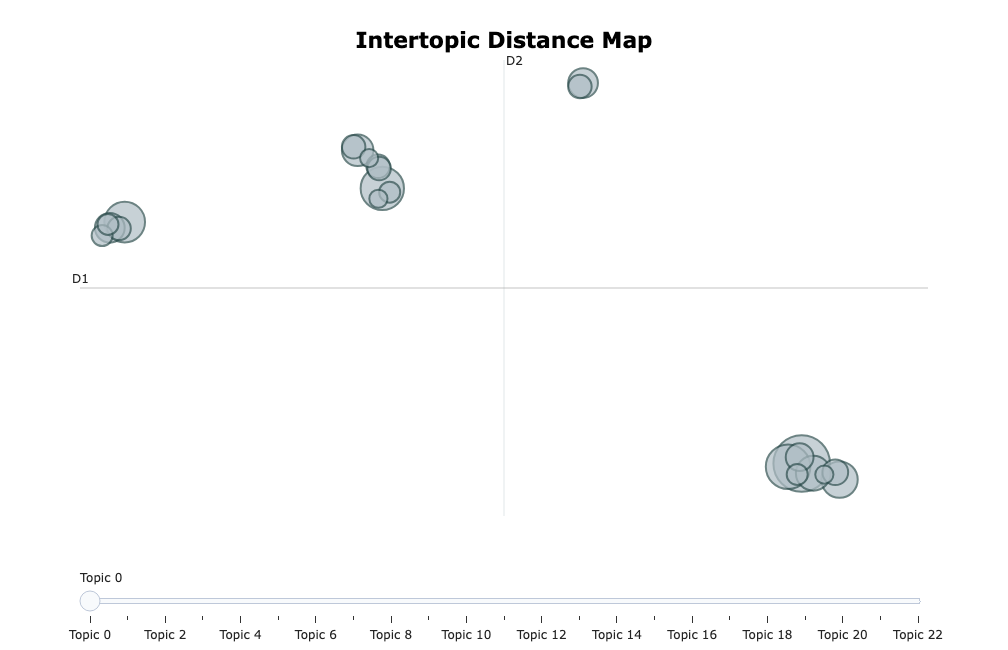

In [90]:
# run this cell to visualize the topics
topic_model.visualize_topics()